In [1]:
%pip install yfinance pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas as pd

# 1. Download historical 5-year data for Apple
print("Fetching data from Yahoo Finance...")
ticker = "AAPL"
stock_data = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# 2. Handle data structure 
if isinstance(stock_data.columns, pd.MultiIndex):
    stock_data.columns = stock_data.columns.get_level_values(0)

# 3. Create Technical Indicators 
stock_data['SMA_20'] = stock_data['Close'].rolling(window=20).mean()
stock_data['SMA_50'] = stock_data['Close'].rolling(window=50).mean()

# Drop rows that don't have enough data
stock_data.dropna(inplace=True)

print("Data successfully loaded and processed!")
print(stock_data[['Close', 'SMA_20', 'SMA_50']].head())

Fetching data from Yahoo Finance...


[*********************100%***********************]  1 of 1 completed

Data successfully loaded and processed!
Price            Close      SMA_20      SMA_50
Date                                          
2021-03-16  122.192032  120.488145  126.283382
2021-03-17  121.403824  120.192322  126.196641
2021-03-18  117.287636  119.745671  125.996484
2021-03-19  116.762146  119.264960  125.871516
2021-03-22  120.070694  119.137971  125.728770


Matplotlib is building the font cache; this may take a moment.


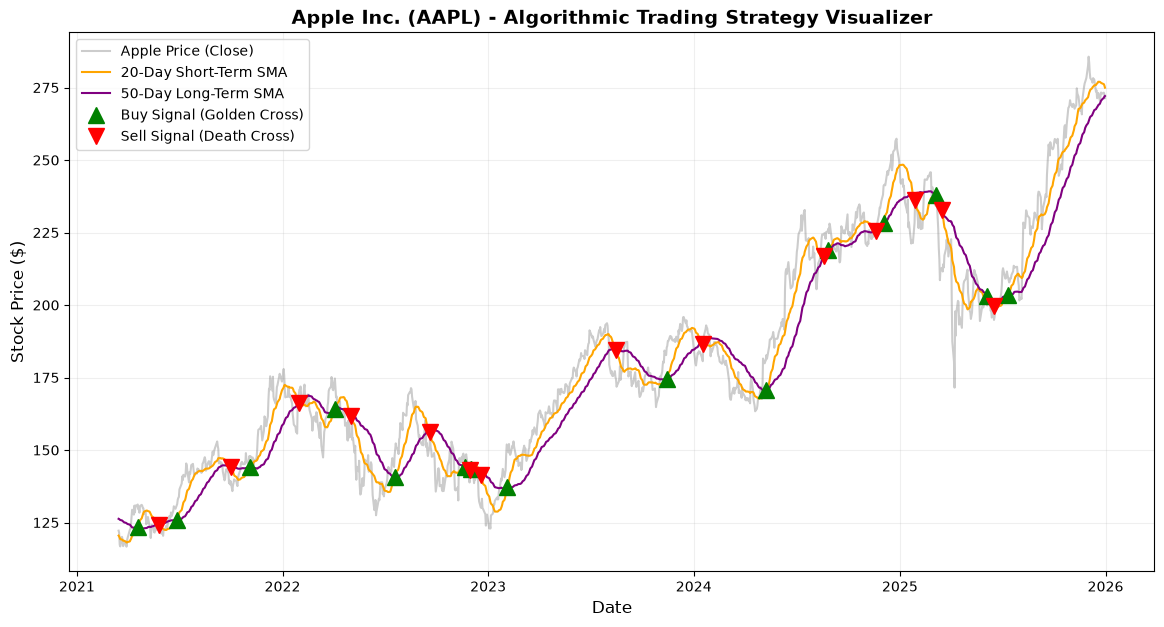

In [3]:
import matplotlib.pyplot as plt

# 1. Generate Buy (1) and Sell (0) Signals
stock_data['Signal'] = 0

# If the short-term trend is higher than the long-term trend, set signal to 1
stock_data.loc[stock_data['SMA_20'] > stock_data['SMA_50'], 'Signal'] = 1

# Find the exact days where the signal flips (1 = Buy trigger, -1 = Sell trigger)
stock_data['Position'] = stock_data['Signal'].diff()

# 2. Set up the plotting canvas
plt.figure(figsize=(14, 7))

# Plot the stock's closing price line
plt.plot(stock_data['Close'], label='Apple Price (Close)', alpha=0.4, color='gray')

# Plot the moving averages
plt.plot(stock_data['SMA_20'], label='20-Day Short-Term SMA', color='orange', linewidth=1.5)
plt.plot(stock_data['SMA_50'], label='50-Day Long-Term SMA', color='purple', linewidth=1.5)

# Plot green upward triangles at the exact rows where a Buy is triggered
plt.plot(stock_data[stock_data['Position'] == 1].index, 
         stock_data['SMA_20'][stock_data['Position'] == 1], 
         '^', markersize=12, color='green', label='Buy Signal (Golden Cross)')

# Plot red downward triangles at the exact rows where a Sell is triggered
plt.plot(stock_data[stock_data['Position'] == -1].index, 
         stock_data['SMA_20'][stock_data['Position'] == -1], 
         'v', markersize=12, color='red', label='Sell Signal (Death Cross)')

# Chart layout adjustments
plt.title('Apple Inc. (AAPL) - Algorithmic Trading Strategy Visualizer', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price ($)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left', fontsize=10)

# Display the final graph
plt.show()

In [5]:
# 1. Calculate the daily percentage return of the stock
stock_data['Daily_Return'] = stock_data['Close'].pct_change()

# 2. Calculate the Strategy's daily return
# We shift the signal by 1 day because if the bot decides to buy today, we get tomorrow's return.
stock_data['Strategy_Return'] = stock_data['Daily_Return'] * stock_data['Signal'].shift(1)

# 3. Track a hypothetical $10,000 investment
initial_investment = 10000
stock_data['Hold_Value'] = initial_investment * (1 + stock_data['Daily_Return']).cumprod()
stock_data['Strategy_Value'] = initial_investment * (1 + stock_data['Strategy_Return']).cumprod()

# 4. Get the final numbers
final_hold = stock_data['Hold_Value'].iloc[-1]
final_strategy = stock_data['Strategy_Value'].iloc[-1]

print("BACKTESTING RESULTS (5 YEARS)")
print(f"Starting Investment: ${initial_investment:,.2f}")
print(f"Value if you just bought and held: ${final_hold:,.2f}")
print(f"Value using the Golden Cross Bot:  ${final_strategy:,.2f}")

BACKTESTING RESULTS (5 YEARS)
Starting Investment: $10,000.00
Value if you just bought and held: $22,207.33
Value using the Golden Cross Bot:  $13,706.32
